Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -878     |
| time/              |          |
|    fps             | 4730     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -853        |
| time/                   |             |
|    fps                  | 3359        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.005089942 |
|    clip_fraction        | 0.0175      |
|    clip_range           | 0.2         |
|    entropy_loss   

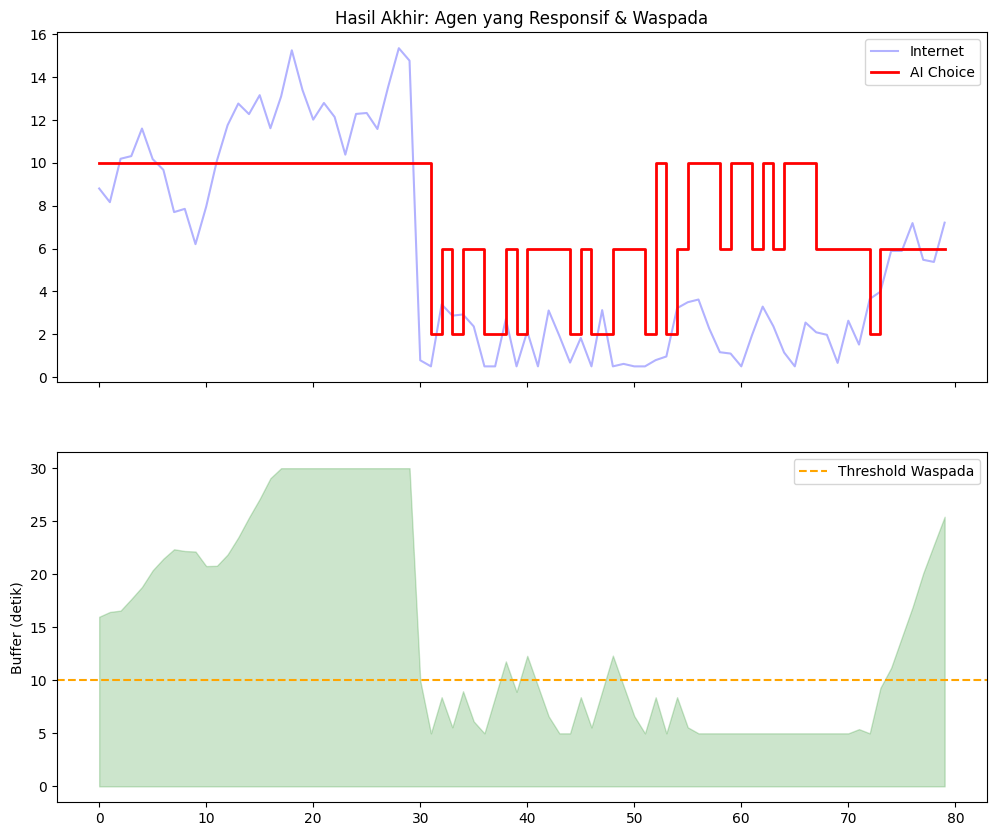

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd

class AdaptiveShakaEnv(gym.Env):
    """
    Simulator Shaka NDN dengan Logika 'Safety First'.
    Agen akan stabil saat internet bagus, tapi sangat responsif saat buffer terancam.
    """
    def __init__(self):
        super(AdaptiveShakaEnv, self).__init__()
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )
        self.state = None
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Mulai dengan buffer sedang
        self.state = np.array([15.0, 10.0, 1.0, 50.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, throughput, last_qual, rtt, dropped = self.state
        chosen_bitrate = self.bitrates[action]
        
        seg_dur = 5.0
        download_time = (chosen_bitrate * seg_dur / (throughput + 0.1)) + (rtt / 1000.0)
        
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # --- LOGIKA REWARD ADAPTIF ---
        
        # 1. Reward Kualitas
        reward = chosen_bitrate 

        # 2. Penalti Macet (Sangat Fatal)
        if stalling > 0:
            reward -= 100.0
        
        # 3. DYNAMIC SWITCHING PENALTY
        # Jika buffer aman (>15s), penalti pindah kualitas besar (biar stabil)
        # Jika buffer kritis (<10s), penalti pindah kualitas nol (biar bebas turun ke Low)
        diff = abs(action - last_qual)
        if diff > 0:
            penalty_weight = 10.0 if new_buffer > 10 else 0.0
            reward -= (diff * penalty_weight)

        # 4. SAFETY PENALTY
        # Menghukum keras jika agen pilih High padahal buffer menipis
        if action == 2 and new_buffer < 8:
            reward -= 20.0

        # Fluktuasi Jaringan NDN
        new_throughput = np.clip(throughput + np.random.uniform(-2, 2.2), 0.5, 20.0)
        new_rtt = np.clip(rtt + np.random.uniform(-20, 20), 10, 500)

        self.state = np.array([new_buffer, new_throughput, float(action), new_rtt, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {}

def train_and_test():
    env = AdaptiveShakaEnv()
    # Tingkatkan ent_coef agar agen lebih berani mencoba-coba saat latihan
    model = PPO("MlpPolicy", env, verbose=1, ent_coef=0.05)
    model.learn(total_timesteps=80000)
    
    # Testing dengan skenario internet drop parah
    obs, _ = env.reset()
    history = []
    for i in range(80):
        if 30 <= i <= 55: # Skenario internet tiba-tiba lemot
            obs[1] = 1.5 
        
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)
        history.append({
            'Step': i,
            'Throughput': obs[1],
            'Buffer': obs[0],
            'Quality': action
        })

    df = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    ax1.plot(df['Step'], df['Throughput'], label='Internet', color='blue', alpha=0.3)
    ax1.step(df['Step'], df['Quality'] * 4 + 2, label='AI Choice', color='red', linewidth=2)
    ax1.set_title("Hasil Akhir: Agen yang Responsif & Waspada")
    ax1.legend()

    ax2.fill_between(df['Step'], df['Buffer'], color='green', alpha=0.2)
    ax2.axhline(y=10, color='orange', linestyle='--', label='Threshold Waspada')
    ax2.set_ylabel("Buffer (detik)")
    ax2.legend()
    plt.show()

if __name__ == "__main__":
    train_and_test()